# Chapter 5: Submanifolds

**Source Span.** `Introduction to Smooth Manifolds.pdf`, Chapter 5, printed pages `98-124`. The course source map identifies this span as embedded and immersed submanifolds, restriction of maps, tangent spaces, and submanifolds with boundary; I inspected the PDF text for the section headings and theorem flow across printed pages 98-124.

**Chapter Goal.** Learn how a subset of an ambient smooth manifold becomes a smooth submanifold, how embedded and immersed cases differ, and how the local models control level sets, tangent spaces, map restrictions, and boundary behavior.

This notebook is not a substitute for the book's proofs line by line. It is a visual and computational companion: each section turns a definition or theorem move into an inspectable model, an invariant check, or a counterexample detector.


## Visual Storyboard

1. **Criteria roadmap.** A proof-dependency graph routes a subset through embeddings, slice charts, level sets, immersions, restriction gates, tangent-space tests, and boundary half-slices. Inspect where each hypothesis is consumed.
2. **Embedded versus immersed examples.** Four planar models compare an embedded graph, two singular zero sets, and a figure-eight immersion. Inspect how full-rank local data can coexist with a problematic global topology.
3. **Slice and level-set local model.** A sphere is shown as a regular level set with a tangent plane and a slice-style local chart. Inspect that tangent vectors are killed by the defining differential.
4. **Tangent-space kernel test.** A circle-level-set calculation compares curve velocities, normal gradients, and the kernel of the differential.
5. **Restriction gates.** A commutative diagram separates the easy domain-restriction theorem from the codomain-restriction theorem, where topology of the target subset matters.
6. **Boundary submanifolds.** A regular domain and a half-slice chart classify inward, outward, and boundary-tangent vectors by a boundary defining function.
7. **Applied lab.** A rank-drop family turns the regular-level-set theorem into a parameter sweep: the same equation is smooth away from one singular parameter and fails exactly at the rank drop.

**Artifact Plan.** All outputs land under `artifacts/chapter-05-submanifolds/` in `figures/`, `html/`, `checks/`, or `tables/`. Filenames name the submanifold concept being tested, not the renderer.


## Library Routing

| Chapter concept | Representation | Library | Why this route | Check |
| --- | --- | --- | --- | --- |
| Embedded/immersed criteria | Directed dependency graph | NetworkX + Matplotlib | The chapter is organized by implications and extra hypotheses | Graph is acyclic and every core section appears |
| Examples and counterexamples | Four-panel planar diagram | NumPy + Matplotlib | The decisive features are local rank and global topology in small Euclidean models | Gradients vanish exactly at singular zero-set examples; immersion speed is nonzero |
| Slice and level-set model | 3D sphere, tangent plane, normal | Plotly HTML + Matplotlib fallback | A level-set submanifold is spatial and benefits from rotation, with a durable PNG fallback | Defining gradient has rank one and tangent residuals vanish |
| Tangent spaces | Symbolic kernel and curve velocity | SymPy + Matplotlib | The tangent result is a linear-algebra identity attached to a visible curve | `grad rho dot v = 0` and symbolic curve derivative agrees |
| Restricting maps | Gate diagram and decision table | NetworkX + CSV | Smoothness after restriction depends on which side is restricted and on topology | Gate table records required hypotheses |
| Boundary submanifolds | Regular domain and half-slice diagram | Matplotlib + SymPy | Boundary direction signs are visible in a local half-space model | Boundary defining function has positive, negative, zero directional signs |
| Rank-drop lab | Parameter sweep of level curves | NumPy + Matplotlib + JSON | Learners can alter one parameter and watch the regular-value hypothesis fail | Critical point lies on the level exactly at the singular parameter |


In [1]:
from pathlib import Path
import csv
import json
import math
import os
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch, Rectangle
import networkx as nx
import numpy as np
import plotly.graph_objects as go
import sympy as sp

NOTEBOOK_DIR = Path.cwd()
BOOK_ROOT = None
for candidate in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate the Introduction-to-Smooth-Manifolds course root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
)

UNIT_KEY = "chapter-05-submanifolds"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
HTML = ARTIFACT_ROOT / "html"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"
SOURCE_SPAN = {
    "pdf": "Introduction to Smooth Manifolds.pdf",
    "chapter": "Chapter 5: Submanifolds",
    "printed_pages": "98-124",
    "source_map_focus": "Embedded and immersed submanifolds, map restriction, tangent spaces, and boundary submanifolds.",
}

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 180,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
})

chapter_artifacts = []

def register(path):
    chapter_artifacts.append(Path(path))
    return path

def book_rel(path):
    return Path(path).resolve().relative_to(BOOK_ROOT.resolve()).as_posix()

def notebook_rel(path):
    return Path(os.path.relpath(Path(path).resolve(), NOTEBOOK_DIR.resolve()))

def show(path, width=760, height=520):
    display_artifact(notebook_rel(path), width=width, height=height)


## Translation Guide

The chapter uses several nearby words that should not be collapsed:

- **Embedded submanifold:** a subset with the subspace topology and the unique smooth structure making the inclusion an embedding. In computations, look for slice coordinates, regular level sets, graphs, or a closed/proper embedding test.
- **Immersed submanifold:** a subset may carry a topology finer than the subspace topology, with inclusion only an immersion. In computations, inspect local rank separately from global topology.
- **Local slice condition:** after a suitable ambient chart, the subset is cut out by setting ambient coordinates constant. This is the local normal form for embedded submanifolds.
- **Local defining map:** a submersion whose level set is the submanifold locally. Its differential gives the tangent space by a kernel.
- **Restriction of maps:** restricting the domain to a submanifold is automatic; restricting the codomain to a submanifold needs a topology condition unless the submanifold is embedded or weakly embedded.
- **Boundary submanifold:** replace slices by half-slices at boundary points; inward/outward direction is detected by the sign of a boundary defining function.


## 1. Roadmap of the Chapter

Read the graph from left to right. The point is not that every route is equivalent. The point is to see which extra hypothesis turns a subset into an embedded object, which only produces an immersed object, and where later theorems reuse the local model.


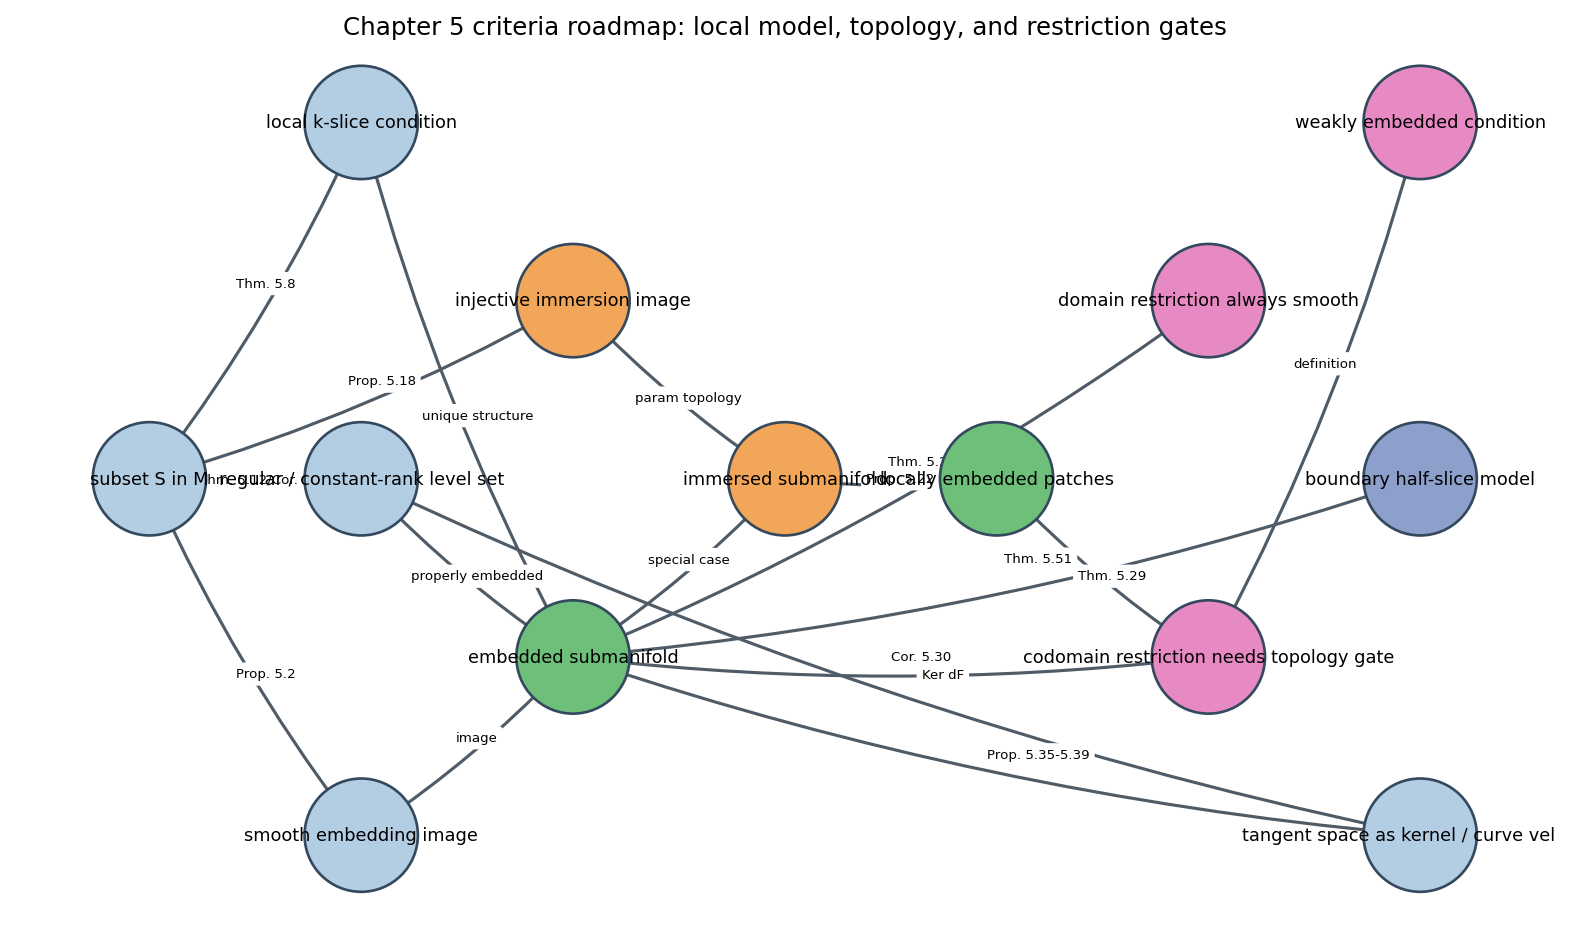

In [2]:
roadmap_nodes = {
    "subset S in M": 0,
    "smooth embedding image": 1,
    "local k-slice condition": 1,
    "regular / constant-rank level set": 1,
    "embedded submanifold": 2,
    "injective immersion image": 2,
    "immersed submanifold": 3,
    "locally embedded patches": 4,
    "domain restriction always smooth": 5,
    "codomain restriction needs topology gate": 5,
    "weakly embedded condition": 6,
    "tangent space as kernel / curve velocity": 6,
    "boundary half-slice model": 6,
}
roadmap_edges = [
    ("subset S in M", "smooth embedding image", "Prop. 5.2"),
    ("smooth embedding image", "embedded submanifold", "image"),
    ("subset S in M", "local k-slice condition", "Thm. 5.8"),
    ("local k-slice condition", "embedded submanifold", "unique structure"),
    ("subset S in M", "regular / constant-rank level set", "Thm. 5.12/Cor. 5.14"),
    ("regular / constant-rank level set", "embedded submanifold", "properly embedded"),
    ("subset S in M", "injective immersion image", "Prop. 5.18"),
    ("injective immersion image", "immersed submanifold", "param topology"),
    ("embedded submanifold", "immersed submanifold", "special case"),
    ("immersed submanifold", "locally embedded patches", "Prop. 5.22"),
    ("locally embedded patches", "codomain restriction needs topology gate", "Thm. 5.29"),
    ("embedded submanifold", "domain restriction always smooth", "Thm. 5.27"),
    ("embedded submanifold", "codomain restriction needs topology gate", "Cor. 5.30"),
    ("codomain restriction needs topology gate", "weakly embedded condition", "definition"),
    ("embedded submanifold", "tangent space as kernel / curve velocity", "Prop. 5.35-5.39"),
    ("regular / constant-rank level set", "tangent space as kernel / curve velocity", "Ker dF"),
    ("embedded submanifold", "boundary half-slice model", "Thm. 5.51"),
]

G = nx.DiGraph()
for node, layer in roadmap_nodes.items():
    G.add_node(node, layer=layer)
for source, target, label in roadmap_edges:
    G.add_edge(source, target, label=label)

fig, ax = plt.subplots(figsize=(12.4, 7.0))
pos = nx.multipartite_layout(G, subset_key="layer", align="vertical", scale=3.0)
colors = []
for node in G.nodes:
    if "embedded" in node and "weakly" not in node:
        colors.append("#6dbf7a")
    elif "immersed" in node or "immersion" in node:
        colors.append("#f2a65a")
    elif "boundary" in node:
        colors.append("#8da0cb")
    elif "restriction" in node or "weakly" in node:
        colors.append("#e78ac3")
    else:
        colors.append("#b3cde3")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=2600, linewidths=1.2, edgecolors="#34495e")
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", width=1.4, edge_color="#4f5b66", connectionstyle="arc3,rad=0.06")
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
edge_labels = {(u, v): data["label"] for u, v, data in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6, ax=ax, rotate=False, label_pos=0.55)
ax.set_title("Chapter 5 criteria roadmap: local model, topology, and restriction gates")
ax.axis("off")
roadmap_path = register(save_matplotlib(fig, FIGURES / "submanifold-criteria-roadmap.png"))
plt.close(fig)

routing_rows = [
    {"concept": "embedded submanifold", "artifact": "submanifold-criteria-roadmap.png", "invariant": "slice/level/embedding routes feed a unique subspace topology"},
    {"concept": "immersed submanifold", "artifact": "embedded-immersed-counterexamples.png", "invariant": "inclusion is locally immersive while topology may differ globally"},
    {"concept": "slice and level set", "artifact": "sphere-level-set-slice.html", "invariant": "rank d rho = 1 on the level set"},
    {"concept": "tangent space", "artifact": "tangent-space-kernel.png", "invariant": "T_p S = ker d rho_p for a regular level set"},
    {"concept": "restricting maps", "artifact": "restriction-weak-embedding-gates.png", "invariant": "domain restriction is automatic; codomain restriction passes a continuity gate"},
    {"concept": "boundary submanifold", "artifact": "boundary-domain-half-slice.png", "invariant": "boundary defining function classifies vector direction by sign"},
    {"concept": "rank-drop lab", "artifact": "applied-lab-rank-drop-family.png", "invariant": "critical point belongs to level exactly at singular parameter"},
]
routing_path = register(save_csv(routing_rows, TABLES / "submanifold-library-routing.csv"))
storyboard_path = register(save_json({
    "source_span": SOURCE_SPAN,
    "roadmap_nodes": list(G.nodes),
    "roadmap_edges": [{"source": u, "target": v, "label": data["label"]} for u, v, data in G.edges(data=True)],
    "dag": nx.is_directed_acyclic_graph(G),
    "library_routes": routing_rows,
}, CHECKS / "storyboard-and-routing.json"))

assert nx.is_directed_acyclic_graph(G)
show(roadmap_path, width=860)


## 2. Embedded Versus Immersed, With Failure Modes

The definition of an embedded submanifold has two parts: smooth local model and subspace topology. The figure below deliberately separates them. A graph is embedded because it has a global parametrization with a continuous inverse from the subspace. The crossing and cusp zero sets fail at the rank test. The figure-eight immersion has nonzero velocity, so it is locally a curve, but its natural smooth topology is not the same as the subspace topology at the crossing behavior.


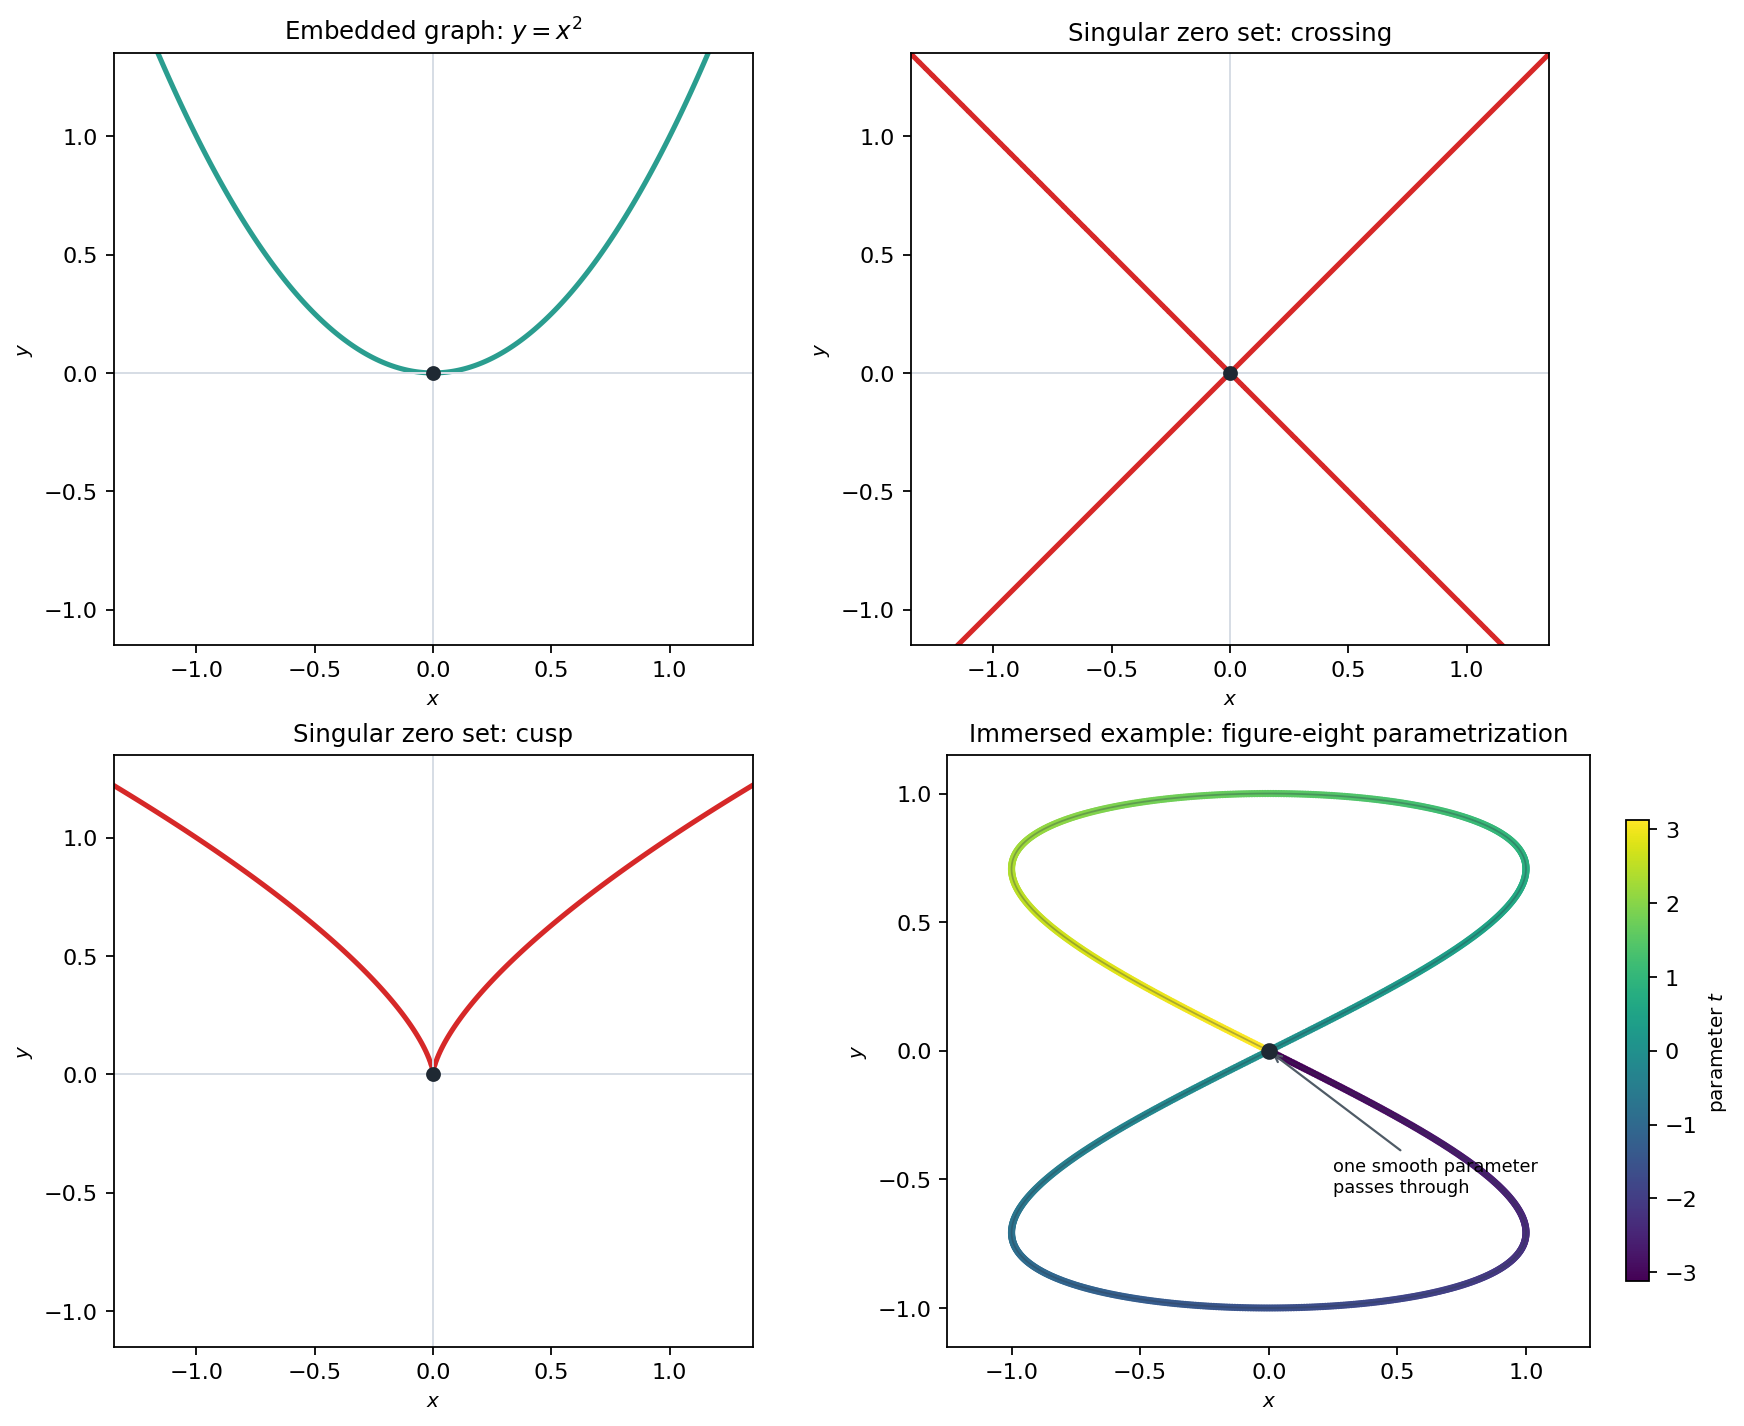

In [3]:
x = np.linspace(-1.5, 1.5, 500)
y = np.linspace(-1.5, 1.5, 500)
X, Y = np.meshgrid(x, y)
F_parabola = X**2 - Y
F_crossing = X**2 - Y**2
F_cusp = X**2 - Y**3

t = np.linspace(-math.pi + 0.015, math.pi - 0.015, 1200)
gamma = np.column_stack([np.sin(2 * t), np.sin(t)])
speed = np.sqrt((2 * np.cos(2 * t))**2 + (np.cos(t))**2)

fig, axes = plt.subplots(2, 2, figsize=(10.8, 8.8), constrained_layout=True)
panels = [
    (axes[0, 0], F_parabola, "Embedded graph: $y=x^2$", "#2a9d8f"),
    (axes[0, 1], F_crossing, "Singular zero set: crossing", "#d62828"),
    (axes[1, 0], F_cusp, "Singular zero set: cusp", "#d62828"),
]
for ax, values, title, color in panels:
    ax.contour(X, Y, values, levels=[0], colors=[color], linewidths=2.3)
    ax.axhline(0, color="#d7dde5", lw=0.9)
    ax.axvline(0, color="#d7dde5", lw=0.9)
    ax.scatter([0], [0], s=32, c="#1f2933", zorder=4)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.15, 1.35)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")

ax = axes[1, 1]
sc = ax.scatter(gamma[:, 0], gamma[:, 1], c=t, cmap="viridis", s=5)
ax.plot(gamma[:, 0], gamma[:, 1], color="#2f3a4a", alpha=0.35, lw=0.8)
ax.scatter([0], [0], s=42, c="#1f2933", zorder=5)
ax.annotate("one smooth parameter\npasses through", xy=(0, 0), xytext=(0.25, -0.55),
            arrowprops={"arrowstyle": "->", "color": "#4f5b66"}, fontsize=8)
ax.set_title("Immersed example: figure-eight parametrization")
ax.set_aspect("equal")
ax.set_xlim(-1.25, 1.25)
ax.set_ylim(-1.15, 1.15)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
cbar = fig.colorbar(sc, ax=ax, shrink=0.78)
cbar.set_label("parameter $t$")

examples_path = register(save_matplotlib(fig, FIGURES / "embedded-immersed-counterexamples.png"))
plt.close(fig)

example_checks = {
    "parabola_gradient_at_origin": [0.0, -1.0],
    "parabola_regular_at_origin": True,
    "crossing_gradient_at_origin": [0.0, 0.0],
    "cusp_gradient_at_origin": [0.0, 0.0],
    "singular_zero_sets_fail_regular_value_test_at_origin": True,
    "figure_eight_min_sampled_speed": float(speed.min()),
    "figure_eight_sampled_immersion_test": bool(speed.min() > 0.05),
    "inspection_note": "The sampled speed is bounded away from zero on the open interval, while the image exhibits the global topology issue discussed for immersed nonembedded examples.",
}
examples_check_path = register(save_json(example_checks, CHECKS / "embedded-immersed-counterexamples.json"))
assert example_checks["parabola_regular_at_origin"]
assert example_checks["crossing_gradient_at_origin"] == [0.0, 0.0]
assert example_checks["cusp_gradient_at_origin"] == [0.0, 0.0]
assert example_checks["figure_eight_sampled_immersion_test"]
show(examples_path, width=820)


## 3. Slice Charts and Regular Level Sets

The local slice criterion says that an embedded \(k\)-submanifold of an \(n\)-manifold can be made, in ambient coordinates, to look like \(x_{k+1}=c_{k+1},\ldots,x_n=c_n\). The level-set theorem supplies this model when a defining map has constant rank. For the unit sphere, \(\rho(x,y,z)=x^2+y^2+z^2\) has nonzero differential on \(\rho^{-1}(1)\), and the tangent plane is the kernel of \(d\rho\).


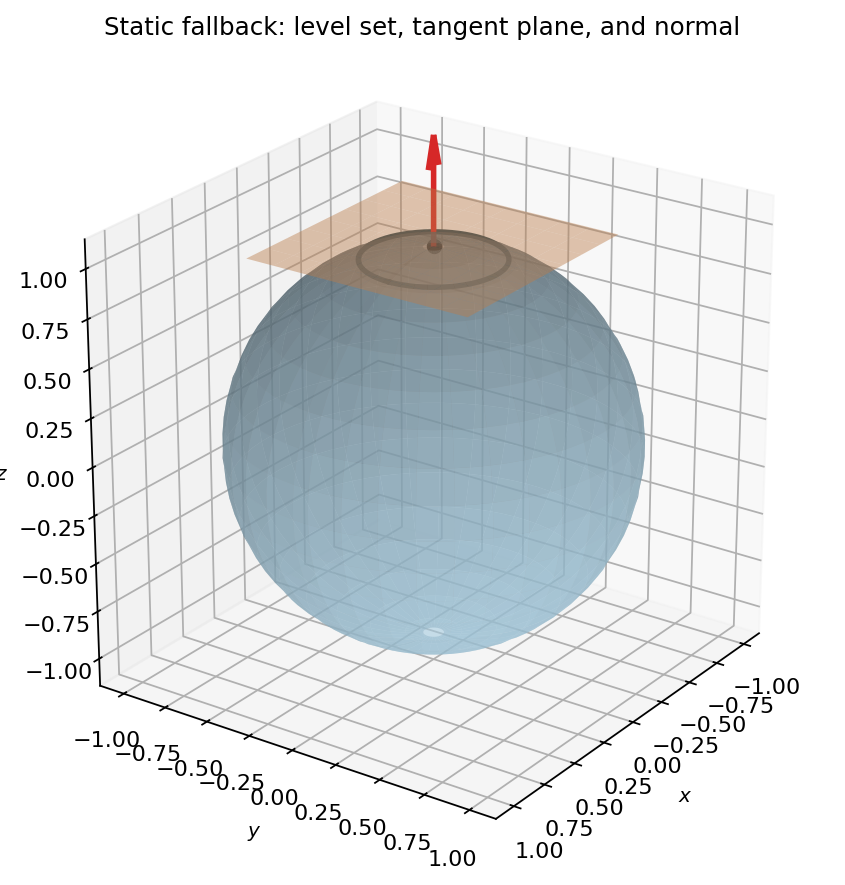

D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


In [4]:
u = np.linspace(0, 2 * np.pi, 72)
v = np.linspace(0.05, np.pi - 0.05, 36)
U, V = np.meshgrid(u, v)
sphere_x = np.cos(U) * np.sin(V)
sphere_y = np.sin(U) * np.sin(V)
sphere_z = np.cos(V)

p = np.array([0.0, 0.0, 1.0])
tangent_u = np.array([1.0, 0.0, 0.0])
tangent_v = np.array([0.0, 1.0, 0.0])
grid_plane = np.linspace(-0.62, 0.62, 9)
PX, PY = np.meshgrid(grid_plane, grid_plane)
PZ = np.ones_like(PX)

plotly_fig = go.Figure()
plotly_fig.add_surface(x=sphere_x, y=sphere_y, z=sphere_z, opacity=0.58, colorscale="Viridis", showscale=False, name="sphere")
plotly_fig.add_surface(x=PX, y=PY, z=PZ, opacity=0.45, colorscale=[[0, "#f4a261"], [1, "#f4a261"]], showscale=False, name="tangent plane")
plotly_fig.add_trace(go.Scatter3d(x=[0, 0], y=[0, 0], z=[1, 1.55], mode="lines+markers", line={"color": "#d62828", "width": 7}, marker={"size": 3}, name="normal grad rho"))
theta = np.linspace(0, 2 * np.pi, 200)
small_r = 0.35
chart_curve = np.column_stack([small_r * np.cos(theta), small_r * np.sin(theta), np.sqrt(1 - small_r**2) * np.ones_like(theta)])
plotly_fig.add_trace(go.Scatter3d(x=chart_curve[:, 0], y=chart_curve[:, 1], z=chart_curve[:, 2], mode="lines", line={"color": "#264653", "width": 5}, name="local latitude in slice chart"))
plotly_fig.update_layout(
    title="Sphere as a regular level set with a tangent kernel",
    scene={"aspectmode": "cube", "xaxis_title": "x", "yaxis_title": "y", "zaxis_title": "z"},
    margin={"l": 0, "r": 0, "b": 0, "t": 45},
    height=620,
)
sphere_html_path = HTML / "sphere-level-set-slice.html"
plotly_fig.write_html(str(sphere_html_path), include_plotlyjs=True, full_html=True)
register(sphere_html_path)

fig = plt.figure(figsize=(8.2, 6.6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(sphere_x, sphere_y, sphere_z, color="#a6cee3", alpha=0.58, linewidth=0, rstride=2, cstride=2)
ax.plot_surface(PX, PY, PZ, color="#f4a261", alpha=0.44, linewidth=0)
ax.quiver(0, 0, 1, 0, 0, 0.55, color="#d62828", linewidth=2.5)
ax.plot(chart_curve[:, 0], chart_curve[:, 1], chart_curve[:, 2], color="#264653", lw=2.4)
ax.scatter([0], [0], [1], color="#1f2933", s=35)
ax.set_title("Static fallback: level set, tangent plane, and normal")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$z$")
ax.set_box_aspect((1, 1, 1))
ax.view_init(elev=24, azim=35)
sphere_png_path = register(save_matplotlib(fig, FIGURES / "local-slice-level-set.png"))
plt.close(fig)

gradient_p = 2 * p
tangent_residuals = [float(np.dot(gradient_p, tangent_u)), float(np.dot(gradient_p, tangent_v))]
radius_residual = float(np.max(np.abs(sphere_x**2 + sphere_y**2 + sphere_z**2 - 1)))
sphere_checks = {
    "defining_function": "rho(x,y,z)=x^2+y^2+z^2",
    "level": 1,
    "point": p.tolist(),
    "gradient_at_point": gradient_p.tolist(),
    "rank_of_d_rho_at_point": 1,
    "tangent_basis": [tangent_u.tolist(), tangent_v.tolist()],
    "gradient_dot_tangent_basis": tangent_residuals,
    "max_radius_residual_on_mesh": radius_residual,
    "local_slice_message": "Near the north pole, z=sqrt(1-x^2-y^2) makes the sphere a graph over the tangent coordinate plane.",
}
sphere_check_path = register(save_json(sphere_checks, CHECKS / "local-slice-level-set.json"))
assert sphere_checks["rank_of_d_rho_at_point"] == 1
assert max(abs(r) for r in tangent_residuals) < 1e-12
assert radius_residual < 1e-12

show(sphere_png_path, width=720)
show(sphere_html_path, width=760, height=560)


## 4. Tangent Spaces Inside the Ambient Tangent Space

Once the inclusion \(S \hookrightarrow M\) is fixed, \(T_pS\) is viewed as a linear subspace of \(T_pM\). For an embedded level set, the defining map makes this concrete: \(T_pS=\ker d\rho_p\). The circle model below checks the same vector three ways: as a curve velocity, as a vector perpendicular to the gradient, and as an annihilator of a function that vanishes on the submanifold.


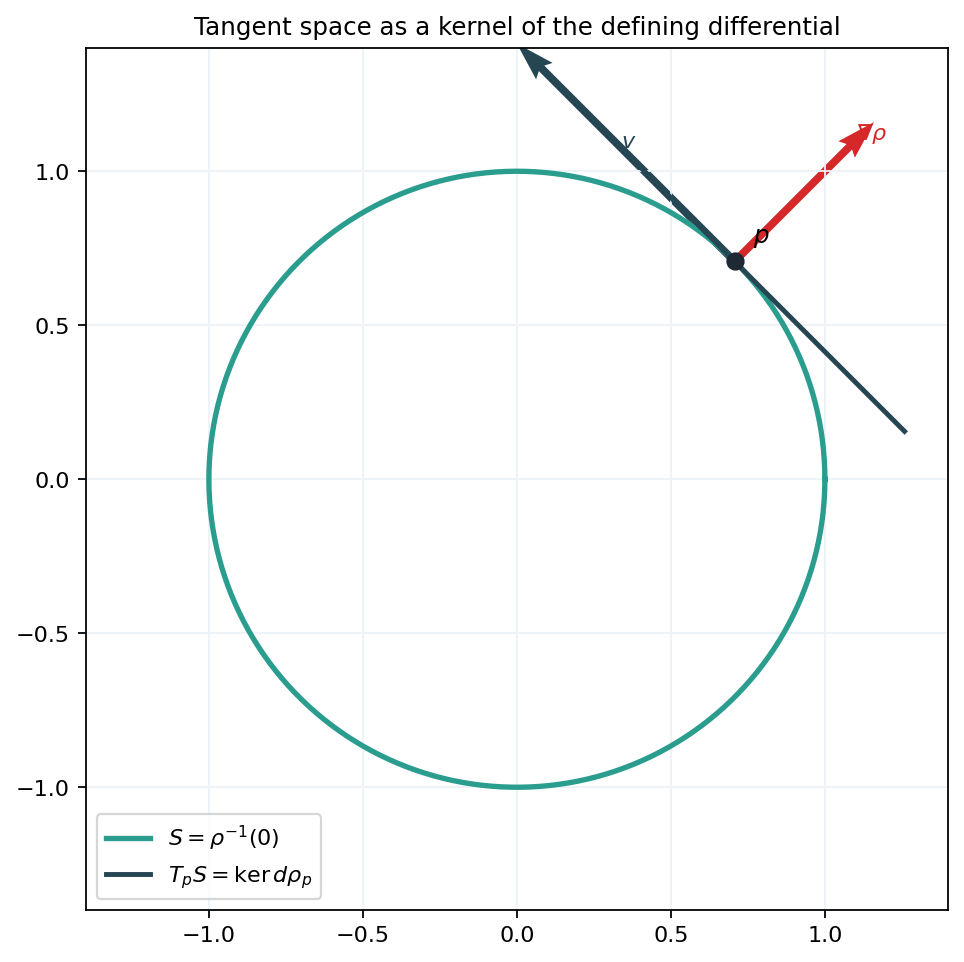

In [5]:
theta0 = math.pi / 4
p2 = np.array([math.cos(theta0), math.sin(theta0)])
tangent = np.array([-math.sin(theta0), math.cos(theta0)])
normal = 2 * p2

sx, sy, st = sp.symbols("x y t", real=True)
theta0_sym = sp.pi / 4
p2_exact = {sx: sp.sqrt(2) / 2, sy: sp.sqrt(2) / 2}
tangent_exact = sp.Matrix([-sp.sqrt(2) / 2, sp.sqrt(2) / 2])
rho = sx**2 + sy**2 - 1
gamma_sym = sp.Matrix([sp.cos(theta0_sym + st), sp.sin(theta0_sym + st)])
gamma_prime = sp.diff(gamma_sym, st).subs(st, 0)
grad_rho = sp.Matrix([sp.diff(rho, sx), sp.diff(rho, sy)]).subs(p2_exact)
symbolic_dot = sp.simplify((grad_rho.T * gamma_prime)[0])
h = sx + 2 * sy
vanishing_function = rho * h
directional_vanish = sp.simplify(
    tangent_exact[0] * sp.diff(vanishing_function, sx).subs(p2_exact)
    + tangent_exact[1] * sp.diff(vanishing_function, sy).subs(p2_exact)
)

circle = np.linspace(0, 2 * np.pi, 400)
C = np.column_stack([np.cos(circle), np.sin(circle)])
line_s = np.linspace(-0.78, 0.78, 100)
tangent_line = p2 + line_s[:, None] * tangent

fig, ax = plt.subplots(figsize=(7.4, 7.0))
ax.plot(C[:, 0], C[:, 1], color="#2a9d8f", lw=2.4, label="$S=\\rho^{-1}(0)$")
ax.plot(tangent_line[:, 0], tangent_line[:, 1], color="#264653", lw=2.2, label="$T_pS=\\ker d\\rho_p$")
ax.quiver(p2[0], p2[1], tangent[0], tangent[1], angles="xy", scale_units="xy", scale=1, color="#264653", width=0.009)
ax.quiver(p2[0], p2[1], 0.32 * normal[0], 0.32 * normal[1], angles="xy", scale_units="xy", scale=1, color="#d62828", width=0.009)
ax.scatter([p2[0]], [p2[1]], s=52, color="#1f2933", zorder=5)
ax.text(p2[0] + 0.06, p2[1] + 0.06, "$p$", fontsize=11)
ax.text(p2[0] + 0.28 * normal[0], p2[1] + 0.28 * normal[1], "$\\nabla\\rho$", color="#d62828")
ax.text(p2[0] + 0.52 * tangent[0], p2[1] + 0.52 * tangent[1], "$v$", color="#264653")
ax.set_title("Tangent space as a kernel of the defining differential")
ax.set_aspect("equal")
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)
ax.grid(True, color="#edf2f7")
ax.legend(loc="lower left")
tangent_path = register(save_matplotlib(fig, FIGURES / "tangent-space-kernel.png"))
plt.close(fig)

tangent_checks = {
    "point": p2.tolist(),
    "tangent_vector": tangent.tolist(),
    "normal_gradient": normal.tolist(),
    "numeric_gradient_dot_tangent": float(np.dot(normal, tangent)),
    "symbolic_curve_velocity": [str(sp.simplify(entry)) for entry in gamma_prime],
    "symbolic_gradient_dot_curve_velocity": str(symbolic_dot),
    "directional_derivative_of_rho_times_h": str(directional_vanish),
    "interpretation": "The tangent vector kills the defining function and therefore every multiple of it that vanishes on the circle.",
}
tangent_check_path = register(save_json(tangent_checks, CHECKS / "tangent-space-kernel.json"))
assert abs(tangent_checks["numeric_gradient_dot_tangent"]) < 1e-12
assert symbolic_dot == 0
assert sp.simplify(directional_vanish) == 0
show(tangent_path, width=680)


## 5. Restricting Maps to and from Submanifolds

Restricting the **domain** of a smooth map is formal: compose the inclusion \(S\hookrightarrow M\) with the map out of \(M\). Restricting the **codomain** is subtler: a map whose image lies in an immersed submanifold must also be continuous for the submanifold topology. The embedded case passes this gate automatically because the submanifold topology is the subspace topology. Weakly embedded submanifolds are exactly the immersed submanifolds designed to pass this gate for every smooth ambient map.


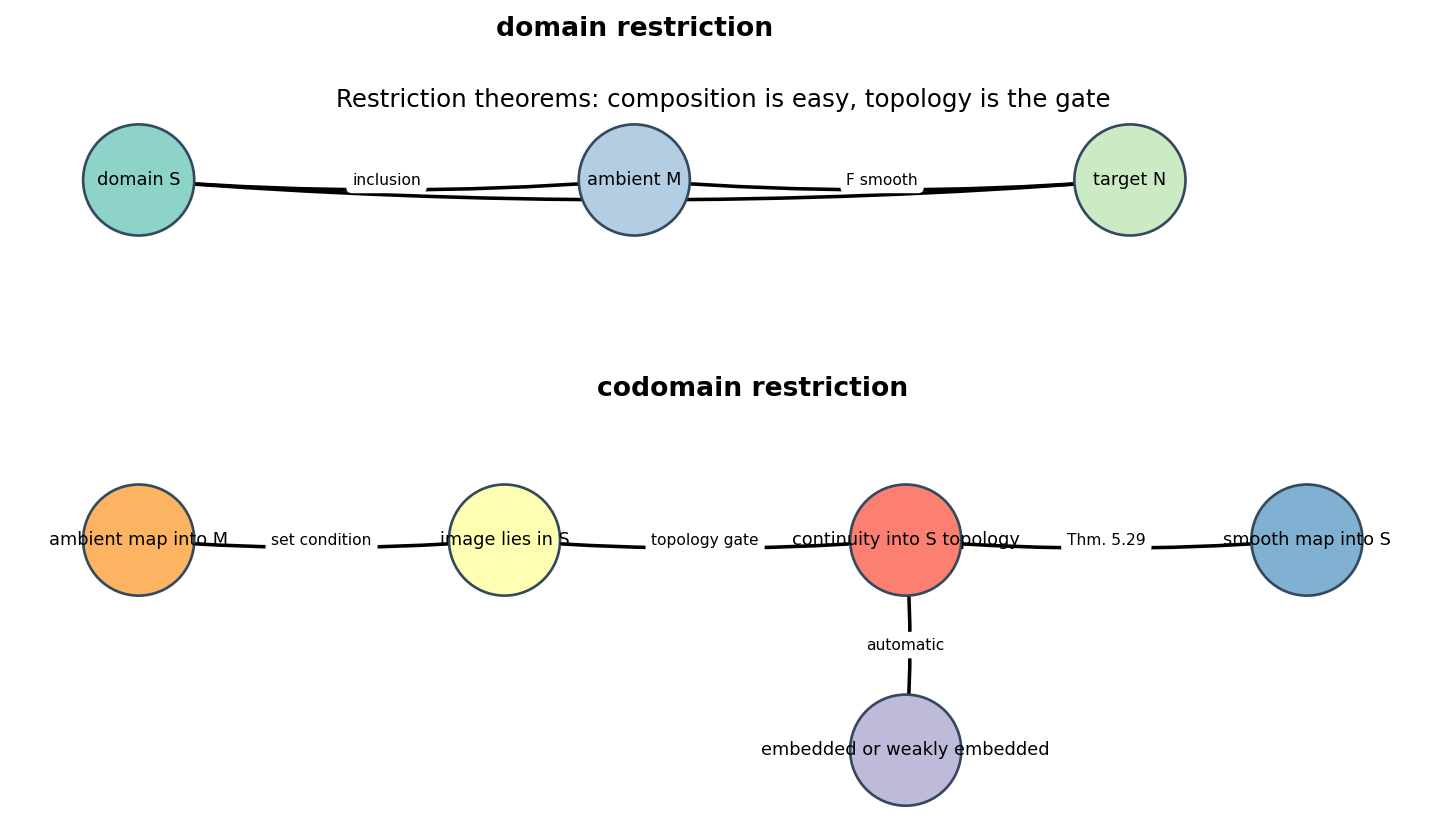

In [6]:
restriction_graph = nx.DiGraph()
restriction_graph.add_node("domain S", layer=0, kind="domain")
restriction_graph.add_node("ambient M", layer=1, kind="ambient")
restriction_graph.add_node("target N", layer=2, kind="target")
restriction_graph.add_node("ambient map into M", layer=0, kind="map")
restriction_graph.add_node("image lies in S", layer=1, kind="condition")
restriction_graph.add_node("continuity into S topology", layer=2, kind="gate")
restriction_graph.add_node("smooth map into S", layer=3, kind="result")
restriction_graph.add_node("embedded or weakly embedded", layer=2, kind="shortcut")
restriction_graph.add_edges_from([
    ("domain S", "ambient M", {"label": "inclusion"}),
    ("ambient M", "target N", {"label": "F smooth"}),
    ("domain S", "target N", {"label": "F|S smooth"}),
    ("ambient map into M", "image lies in S", {"label": "set condition"}),
    ("image lies in S", "continuity into S topology", {"label": "topology gate"}),
    ("continuity into S topology", "smooth map into S", {"label": "Thm. 5.29"}),
    ("embedded or weakly embedded", "continuity into S topology", {"label": "automatic"}),
])
pos = {
    "domain S": (0, 2.0),
    "ambient M": (2.1, 2.0),
    "target N": (4.2, 2.0),
    "ambient map into M": (0, 0.2),
    "image lies in S": (1.55, 0.2),
    "continuity into S topology": (3.25, 0.2),
    "smooth map into S": (4.95, 0.2),
    "embedded or weakly embedded": (3.25, -0.85),
}
color_by_kind = {
    "domain": "#8dd3c7",
    "ambient": "#b3cde3",
    "target": "#ccebc5",
    "map": "#fdb462",
    "condition": "#ffffb3",
    "gate": "#fb8072",
    "result": "#80b1d3",
    "shortcut": "#bebada",
}
node_colors = [color_by_kind[restriction_graph.nodes[n]["kind"]] for n in restriction_graph.nodes]
fig, ax = plt.subplots(figsize=(11.4, 5.6))
nx.draw_networkx_nodes(restriction_graph, pos, ax=ax, node_color=node_colors, edgecolors="#34495e", linewidths=1.2, node_size=2500)
nx.draw_networkx_labels(restriction_graph, pos, ax=ax, font_size=8)
nx.draw_networkx_edges(restriction_graph, pos, ax=ax, arrows=True, arrowstyle="-|>", width=1.6, connectionstyle="arc3,rad=0.04")
edge_labels = {(u, v): d["label"] for u, v, d in restriction_graph.edges(data=True)}
nx.draw_networkx_edge_labels(restriction_graph, pos, edge_labels=edge_labels, font_size=7, ax=ax, rotate=False)
ax.text(2.1, 2.72, "domain restriction", ha="center", fontsize=12, weight="bold")
ax.text(2.6, 0.92, "codomain restriction", ha="center", fontsize=12, weight="bold")
ax.set_title("Restriction theorems: composition is easy, topology is the gate")
ax.axis("off")
restriction_path = register(save_matplotlib(fig, FIGURES / "restriction-weak-embedding-gates.png"))
plt.close(fig)

gate_rows = [
    {"operation": "restrict domain", "hypotheses": "F:M->N smooth, S immersed or embedded in M", "result": "F|S:S->N smooth", "extra_gate": "none"},
    {"operation": "restrict codomain", "hypotheses": "F:N->M smooth, image in immersed S", "result": "F:N->S smooth", "extra_gate": "F must be continuous into the topology on S"},
    {"operation": "embedded codomain case", "hypotheses": "S embedded and image in S", "result": "F:N->S smooth", "extra_gate": "automatic by subspace topology"},
    {"operation": "weakly embedded case", "hypotheses": "S weakly embedded and image in S", "result": "F:N->S smooth", "extra_gate": "built into the definition"},
]
gate_table_path = register(save_csv(gate_rows, TABLES / "restriction-gates.csv"))
restriction_checks = {
    "domain_restriction_requires_extra_topology_gate": False,
    "codomain_restriction_requires_continuity_for_immersed_submanifold": True,
    "embedded_case_passes_automatically": True,
    "weakly_embedded_definition_captured": True,
    "gate_rows": gate_rows,
}
restriction_check_path = register(save_json(restriction_checks, CHECKS / "restriction-weak-embedding-gates.json"))
assert restriction_checks["codomain_restriction_requires_continuity_for_immersed_submanifold"]
assert restriction_checks["embedded_case_passes_automatically"]
show(restriction_path, width=860)


## 6. Boundary Submanifolds, Regular Domains, and Half-Slices

A submanifold with boundary has the same embedded/immersed distinction, but the local model at boundary points is a half-slice rather than a full slice. A regular domain is the codimension-zero embedded case with boundary. The sign test below uses a boundary defining function \(b=1-x^2-y^2\) for the closed unit disk: positive derivative points inward, negative points outward, and zero stays tangent to the boundary.


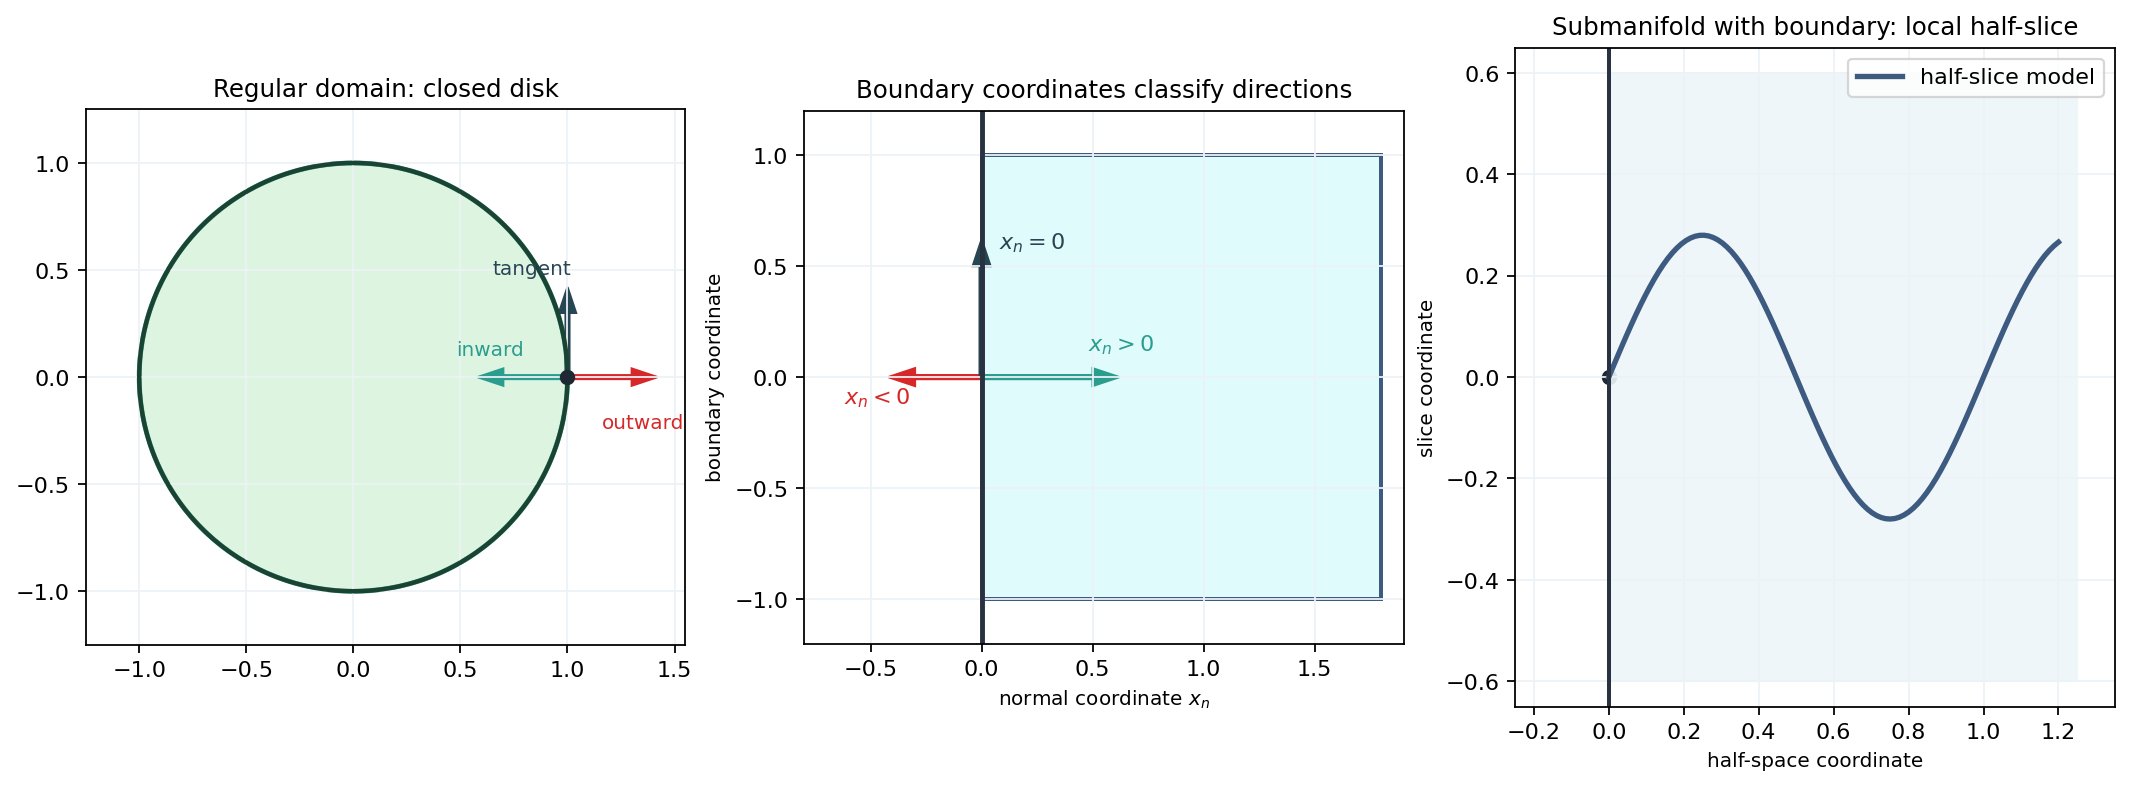

In [7]:
disk_theta = np.linspace(0, 2 * np.pi, 400)
disk = np.column_stack([np.cos(disk_theta), np.sin(disk_theta)])
p_boundary = np.array([1.0, 0.0])
inward = np.array([-0.42, 0.0])
outward = np.array([0.42, 0.0])
tangent_boundary = np.array([0.0, 0.42])

fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.8), constrained_layout=True)
ax = axes[0]
ax.add_patch(Circle((0, 0), 1.0, facecolor="#d8f3dc", edgecolor="#2a9d8f", lw=2.2, alpha=0.85))
ax.plot(disk[:, 0], disk[:, 1], color="#1b4332", lw=2)
ax.scatter([p_boundary[0]], [p_boundary[1]], color="#1f2933", s=35, zorder=5)
for vec, color, label, offset in [
    (inward, "#2a9d8f", "inward", (-0.52, 0.10)),
    (outward, "#d62828", "outward", (0.16, -0.24)),
    (tangent_boundary, "#264653", "tangent", (-0.35, 0.48)),
]:
    ax.arrow(p_boundary[0], p_boundary[1], vec[0], vec[1], width=0.018, head_width=0.08, length_includes_head=True, color=color)
    ax.text(p_boundary[0] + offset[0], p_boundary[1] + offset[1], label, color=color, fontsize=9)
ax.set_title("Regular domain: closed disk")
ax.set_aspect("equal")
ax.set_xlim(-1.25, 1.55)
ax.set_ylim(-1.25, 1.25)
ax.grid(True, color="#edf2f7")

ax = axes[1]
ax.add_patch(Rectangle((0, -1.0), 1.8, 2.0, facecolor="#e0fbfc", edgecolor="#3d5a80", lw=1.8))
ax.axvline(0, color="#293241", lw=2.2)
ax.arrow(0, 0, 0.62, 0, width=0.018, head_width=0.08, color="#2a9d8f", length_includes_head=True)
ax.arrow(0, 0, -0.42, 0, width=0.018, head_width=0.08, color="#d62828", length_includes_head=True)
ax.arrow(0, 0, 0, 0.62, width=0.018, head_width=0.08, color="#264653", length_includes_head=True)
ax.text(0.48, 0.12, "$x_n>0$", color="#2a9d8f")
ax.text(-0.62, -0.12, "$x_n<0$", color="#d62828")
ax.text(0.08, 0.58, "$x_n=0$", color="#264653")
ax.set_title("Boundary coordinates classify directions")
ax.set_xlim(-0.8, 1.9)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect("equal")
ax.set_xlabel("normal coordinate $x_n$")
ax.set_ylabel("boundary coordinate")
ax.grid(True, color="#edf2f7")

ax = axes[2]
s = np.linspace(0, 1.2, 100)
ax.plot(s, 0.28 * np.sin(2 * np.pi * s), color="#3d5a80", lw=2.4, label="half-slice model")
ax.scatter([0], [0], color="#1f2933", s=35)
ax.axvline(0, color="#293241", lw=1.8)
ax.fill_betweenx([-0.6, 0.6], 0, 1.25, color="#edf6f9", alpha=0.9)
ax.set_title("Submanifold with boundary: local half-slice")
ax.set_xlim(-0.25, 1.35)
ax.set_ylim(-0.65, 0.65)
ax.set_xlabel("half-space coordinate")
ax.set_ylabel("slice coordinate")
ax.grid(True, color="#edf2f7")
ax.legend(loc="upper right")

boundary_path = register(save_matplotlib(fig, FIGURES / "boundary-domain-half-slice.png"))
plt.close(fig)

bx, by, vx, vy = sp.symbols("x y vx vy", real=True)
b = 1 - bx**2 - by**2
db_v = sp.diff(b, bx).subs({bx: 1, by: 0}) * vx + sp.diff(b, by).subs({bx: 1, by: 0}) * vy
boundary_checks = {
    "boundary_defining_function": "b(x,y)=1-x^2-y^2 for the closed disk",
    "db_at_point_applied_to_v": str(sp.simplify(db_v)),
    "inward_vector": inward.tolist(),
    "outward_vector": outward.tolist(),
    "tangent_vector": tangent_boundary.tolist(),
    "db_inward": float(db_v.subs({vx: inward[0], vy: inward[1]})),
    "db_outward": float(db_v.subs({vx: outward[0], vy: outward[1]})),
    "db_tangent": float(db_v.subs({vx: tangent_boundary[0], vy: tangent_boundary[1]})),
    "half_slice_condition": "At a boundary point, local coordinates model S by an ordinary slice in a half-space.",
}
boundary_check_path = register(save_json(boundary_checks, CHECKS / "boundary-domain-half-slice.json"))
assert boundary_checks["db_inward"] > 0
assert boundary_checks["db_outward"] < 0
assert abs(boundary_checks["db_tangent"]) < 1e-12
show(boundary_path, width=900)


## Applied Lab: Find the Rank Drop Before Trusting a Level Set

The regular-level-set theorem is a test, not a decoration. In the family \(f_\epsilon(x,y)=x^2-y^2-\epsilon\), the gradient vanishes only at the origin. The origin belongs to the zero level exactly when \(\epsilon=0\). That one parameter value is where the zero set crosses itself and stops being a one-dimensional embedded submanifold.


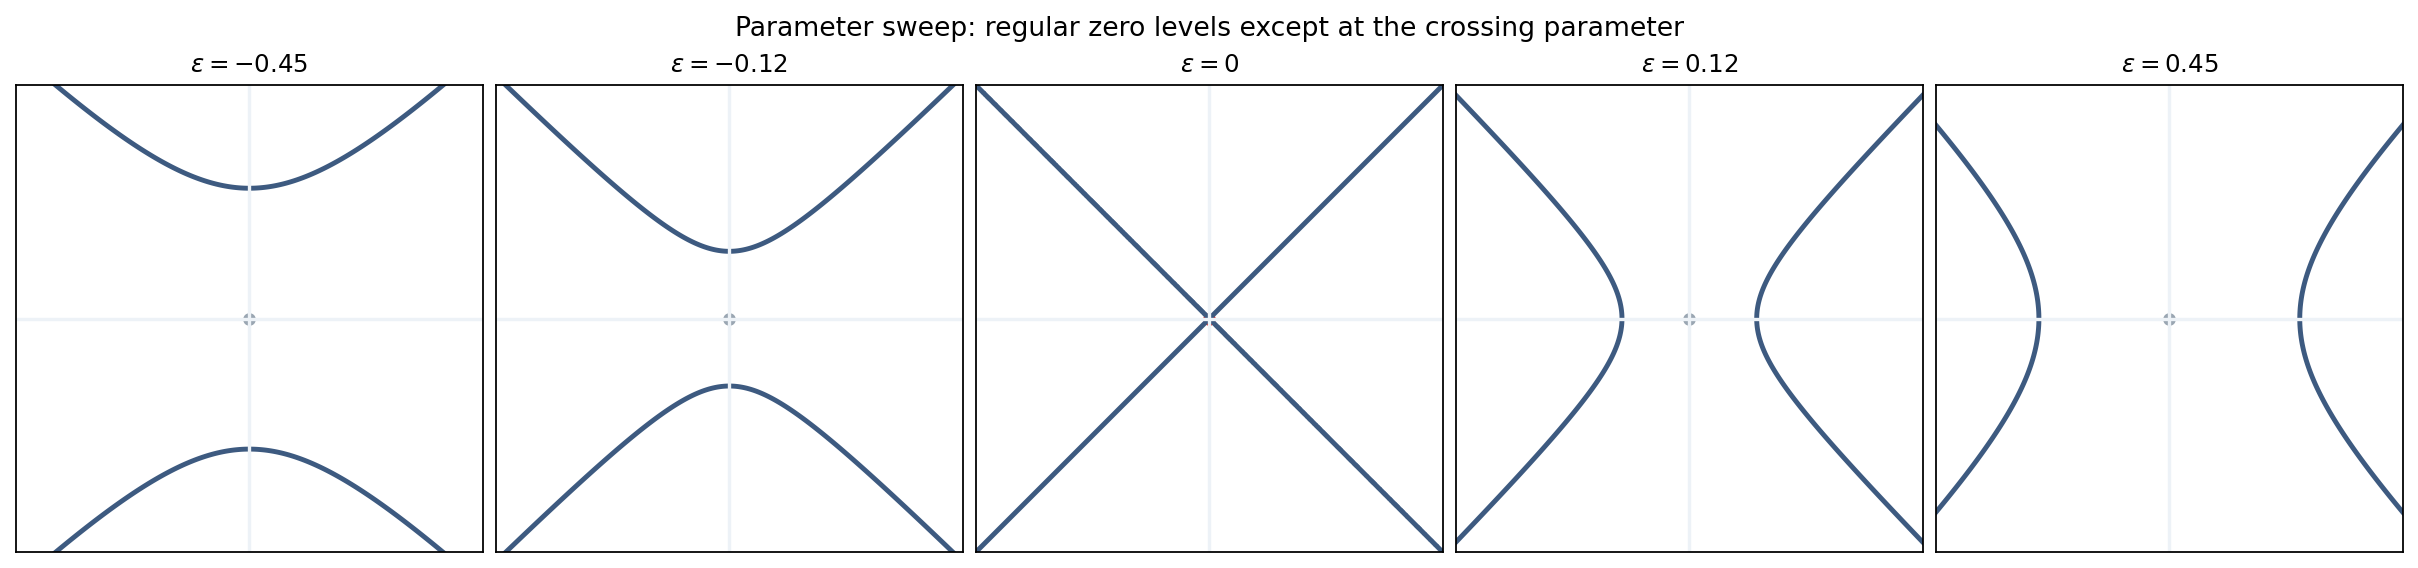

In [8]:
eps_values = [-0.45, -0.12, 0.0, 0.12, 0.45]
grid = np.linspace(-1.35, 1.35, 500)
LX, LY = np.meshgrid(grid, grid)

fig, axes = plt.subplots(1, len(eps_values), figsize=(15.0, 3.6), constrained_layout=True)
lab_rows = []
for ax, eps in zip(axes, eps_values):
    values = LX**2 - LY**2 - eps
    ax.contour(LX, LY, values, levels=[0], colors=["#3d5a80"], linewidths=2.2)
    ax.scatter([0], [0], s=22, color="#d62828" if eps == 0 else "#9aa6b2")
    ax.set_title(f"$\\epsilon={eps:g}$")
    ax.set_aspect("equal")
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.axhline(0, color="#edf2f7")
    ax.axvline(0, color="#edf2f7")
    ax.set_xticks([])
    ax.set_yticks([])
    origin_on_zero_level = bool(abs(-eps) < 1e-12)
    lab_rows.append({
        "epsilon": eps,
        "critical_point": "(0,0)",
        "gradient_at_critical_point": "(0,0)",
        "critical_point_on_zero_level": origin_on_zero_level,
        "regular_zero_level_by_this_test": not origin_on_zero_level,
    })
fig.suptitle("Parameter sweep: regular zero levels except at the crossing parameter")
lab_path = register(save_matplotlib(fig, FIGURES / "applied-lab-rank-drop-family.png"))
plt.close(fig)

lab_table_path = register(save_csv(lab_rows, TABLES / "applied-lab-rank-drop-family.csv"))
lab_check_path = register(save_json({
    "family": "f_epsilon(x,y)=x^2-y^2-epsilon",
    "critical_set": ["(0,0)"],
    "critical_value": 0.0,
    "parameter_rows": lab_rows,
    "singular_parameters": [row["epsilon"] for row in lab_rows if row["critical_point_on_zero_level"]],
}, CHECKS / "applied-lab-rank-drop-family.json"))
assert [row["epsilon"] for row in lab_rows if row["critical_point_on_zero_level"]] == [0.0]
show(lab_path, width=900)


## Takeaways

- Embedded submanifolds are subsets whose topology and smooth structure are forced by the ambient manifold once the local slice condition holds.
- Immersed submanifolds keep the same local rank behavior but may carry a topology that is not the ambient subspace topology.
- Regular and constant-rank level sets are embedded because the defining differential supplies slice coordinates.
- Tangent spaces to embedded level sets are kernels of defining differentials; curve velocities give the same subspace.
- Restricting a map's domain to a submanifold is automatic. Restricting a codomain to an immersed submanifold requires the topology gate.
- Boundary submanifolds use half-slices, and boundary defining functions classify inward, outward, and tangent vectors by sign.


In [9]:
# final_sanity
final_paths = [
    roadmap_path,
    routing_path,
    storyboard_path,
    examples_path,
    examples_check_path,
    sphere_html_path,
    sphere_png_path,
    sphere_check_path,
    tangent_path,
    tangent_check_path,
    restriction_path,
    gate_table_path,
    restriction_check_path,
    boundary_path,
    boundary_check_path,
    lab_path,
    lab_table_path,
    lab_check_path,
]
assert_artifacts(final_paths, min_bytes=80)

with open(storyboard_path, encoding="utf-8") as handle:
    storyboard = json.load(handle)
with open(examples_check_path, encoding="utf-8") as handle:
    examples = json.load(handle)
with open(sphere_check_path, encoding="utf-8") as handle:
    sphere = json.load(handle)
with open(tangent_check_path, encoding="utf-8") as handle:
    tangent_json = json.load(handle)
with open(restriction_check_path, encoding="utf-8") as handle:
    restriction = json.load(handle)
with open(boundary_check_path, encoding="utf-8") as handle:
    boundary = json.load(handle)
with open(lab_check_path, encoding="utf-8") as handle:
    lab = json.load(handle)

sanity = {
    "source_span": SOURCE_SPAN,
    "primary_artifact_count": len(final_paths),
    "artifacts": [book_rel(path) for path in final_paths],
    "checks": {
        "roadmap_is_dag": bool(storyboard["dag"]),
        "parabola_regular_and_singular_examples_detected": bool(examples["parabola_regular_at_origin"] and examples["singular_zero_sets_fail_regular_value_test_at_origin"]),
        "figure_eight_sampled_as_immersion": bool(examples["figure_eight_sampled_immersion_test"]),
        "sphere_tangent_kernel_residual_small": bool(max(abs(v) for v in sphere["gradient_dot_tangent_basis"]) < 1e-12),
        "circle_tangent_kernel_residual_small": bool(abs(tangent_json["numeric_gradient_dot_tangent"]) < 1e-12),
        "restriction_topology_gate_recorded": bool(restriction["codomain_restriction_requires_continuity_for_immersed_submanifold"]),
        "boundary_signs_classify_vectors": bool(boundary["db_inward"] > 0 and boundary["db_outward"] < 0 and abs(boundary["db_tangent"]) < 1e-12),
        "rank_drop_lab_singular_parameter": lab["singular_parameters"],
    },
}
final_sanity_target = CHECKS / "final_sanity.json"
sanity["artifact_count_including_final_sanity"] = len(final_paths) + 1
sanity["final_sanity_artifact"] = book_rel(final_sanity_target)
final_sanity_path = register(save_json(sanity, final_sanity_target))
assert sanity["checks"]["roadmap_is_dag"]
assert sanity["checks"]["parabola_regular_and_singular_examples_detected"]
assert sanity["checks"]["figure_eight_sampled_as_immersion"]
assert sanity["checks"]["sphere_tangent_kernel_residual_small"]
assert sanity["checks"]["circle_tangent_kernel_residual_small"]
assert sanity["checks"]["restriction_topology_gate_recorded"]
assert sanity["checks"]["boundary_signs_classify_vectors"]
assert sanity["checks"]["rank_drop_lab_singular_parameter"] == [0.0]
assert_artifacts([final_sanity_path], min_bytes=80)
show(final_sanity_path)
sanity


`final_sanity.json`

{'source_span': {'pdf': 'Introduction to Smooth Manifolds.pdf',
  'chapter': 'Chapter 5: Submanifolds',
  'printed_pages': '98-124',
  'source_map_focus': 'Embedded and immersed submanifolds, map restriction, tangent spaces, and boundary submanifolds.'},
 'primary_artifact_count': 18,
 'artifacts': ['artifacts/chapter-05-submanifolds/figures/submanifold-criteria-roadmap.png',
  'artifacts/chapter-05-submanifolds/tables/submanifold-library-routing.csv',
  'artifacts/chapter-05-submanifolds/checks/storyboard-and-routing.json',
  'artifacts/chapter-05-submanifolds/figures/embedded-immersed-counterexamples.png',
  'artifacts/chapter-05-submanifolds/checks/embedded-immersed-counterexamples.json',
  'artifacts/chapter-05-submanifolds/html/sphere-level-set-slice.html',
  'artifacts/chapter-05-submanifolds/figures/local-slice-level-set.png',
  'artifacts/chapter-05-submanifolds/checks/local-slice-level-set.json',
  'artifacts/chapter-05-submanifolds/figures/tangent-space-kernel.png',
  'artifa